In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import r3b
import seaborn as sns

%jsroot off

### Helper function to compare parameters from different files

In [2]:
def setup_plots():
    plot, axes = plt.subplots()
    axes.set_xticks(np.arange(0, 1301, step=100))
    axes.set_xticks(np.arange(0, 1301, step=50), minor=True)
    axes.tick_params(axis="x", labelsize=13, labelrotation=-30)
    axes.tick_params(axis="y", labelsize=13)
    axes.grid(which="both", axis="x")
    axes.grid(which="minor", alpha=0.5)
    plot.set_size_inches(13, 6)
    return plot, axes


def compare_par(par_name, pars, labels=[]):
    plot, axes = plt.subplots()
    axes.set_xticks(np.arange(0, 1301, step=100))
    axes.set_xticks(np.arange(0, 1301, step=50), minor=True)
    axes.tick_params(axis="x", labelsize=13, labelrotation=-30)
    axes.tick_params(axis="y", labelsize=13)
    axes.grid(which="both", axis="x")
    axes.grid(which="minor", alpha=0.5)
    plot.set_size_inches(13, 6)
    data = pars
    if labels:
        data = data[data["label"].isin(labels)]
    sns.lineplot(data=data, x="bar_id", y=par_name, ax=axes, hue="label")
    return plot, axes


def show_par_with_errors(par_name, pars, alpha=0.4):
    plot, axes = setup_plots()
    value_name = f"{par_name}.value"
    error_name = f"{par_name}.error"
    sns.lineplot(data=pars, x="bar_id", y=value_name, ax=axes)
    axes.fill_between(pars["bar_id"], pars[value_name] + pars[error_name], pars[value_name] - pars[error_name], alpha=alpha)
    # if is_fill:
    # else:
    #     axes.errorbar(x=pars["bar_id"], y=pars[value_name], yerr=pars[error_name], fmt='.')
    return plot, axes

### Define parameter files with a unique label

Variables to setup:

- `root_path`: the root path used for the calibration of a certain experiment.
- `dir_path`: the subfolder name for a specific test
- `file_maps`: a dictionary with the parameter label as its key and parameter file name as its value

In [18]:
root_path = "/lustre/r3b/ywang/test/s122"
dir_path = "test_aug18"
file_maps = {
    # "millepede": "millepede.par.root",
    "recons": "recons.par.root",
    "millepede": "millepede.test0.par.root",
}

Read the parameter values from files:

In [19]:
all_pars = {}

for label, filename in file_maps.items():
    read_all = True if label == "millepede" else False
    dfs = r3b.neuland.HitParReader(
        filename=f"{root_path}/{dir_path}/{filename}", is_verbose=False
    ).read(read_all)
    if type(dfs) is dict:
        for cycle, df in dfs.items():
            iter_num = int(cycle) - 1
            all_pars[f"{label}_{iter_num}"] = df
            all_pars[f"{label}_{iter_num}"]["iteration"] = iter_num
            all_pars[f"{label}_{iter_num}"]["label"] = f"{label}_{iter_num}"
    else:
        all_pars[f"{label}"] = dfs
        all_pars[f"{label}"]["iteration"] = -1
        all_pars[f"{label}"]["label"] = f"{label}"
all_pars = pd.concat(list(all_pars.values()), ignore_index=True)
iter_max_num = all_pars["iteration"].max()

In [20]:
reference_module_num = 25
ref_t_sync = all_pars[
    (all_pars["bar_id"] == (reference_module_num - 1)) & (all_pars["label"] == "recons")
]["t_sync.value"]
t_syncs = all_pars.loc[all_pars["label"] == "recons", "t_sync.value"]
t_syncs = t_syncs.sub(ref_t_sync.to_numpy()[0])
all_pars.loc[all_pars["label"] == "recons", "t_sync.value"] = t_syncs

## Check the value changes across iterations

Iteration number:
- `-1`: current method (muon track reconstruction)
- `0`: histogram method
- `1~8`: iterations of millepede parameter find tunning

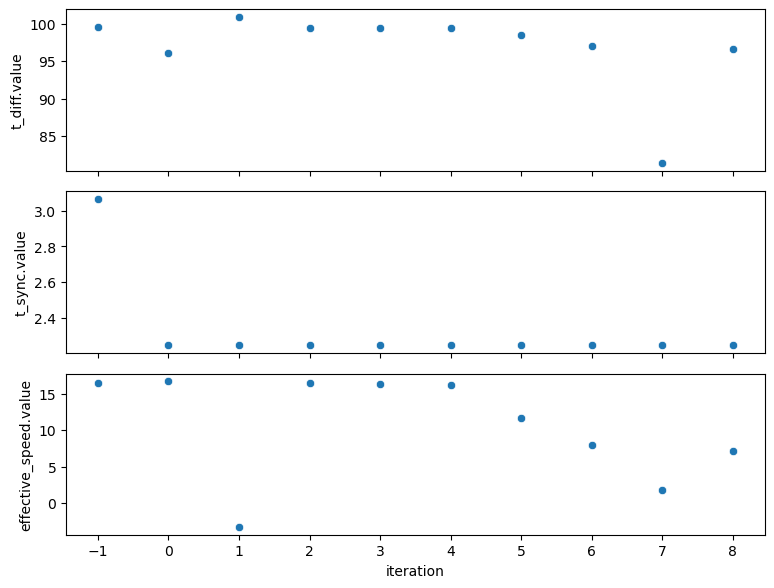

In [30]:
module_id = 5
selected_pars = all_pars[all_pars["bar_id"] == module_id]
# sns.set_context("notebook",rc={'axes.grid' : True})
# sns.set_theme(style="whitegrid")
g = sns.PairGrid(
    selected_pars,
    x_vars="iteration",
    y_vars=["t_diff.value", "t_sync.value", "effective_speed.value"],
    aspect=4,
    height=2,
    despine=False,
)
g.map(sns.scatterplot)
g.set(xticks=range(-1, all_pars["iteration"].max() + 1));

## Parameter comparisons

In [22]:
plot_labels = [
    "recons",
    "millepede_0",
    "millepede_1",
    # "millepede_test",
    f"millepede_{all_pars["iteration"].max()}",
]

### Comparison of t_sync parameter

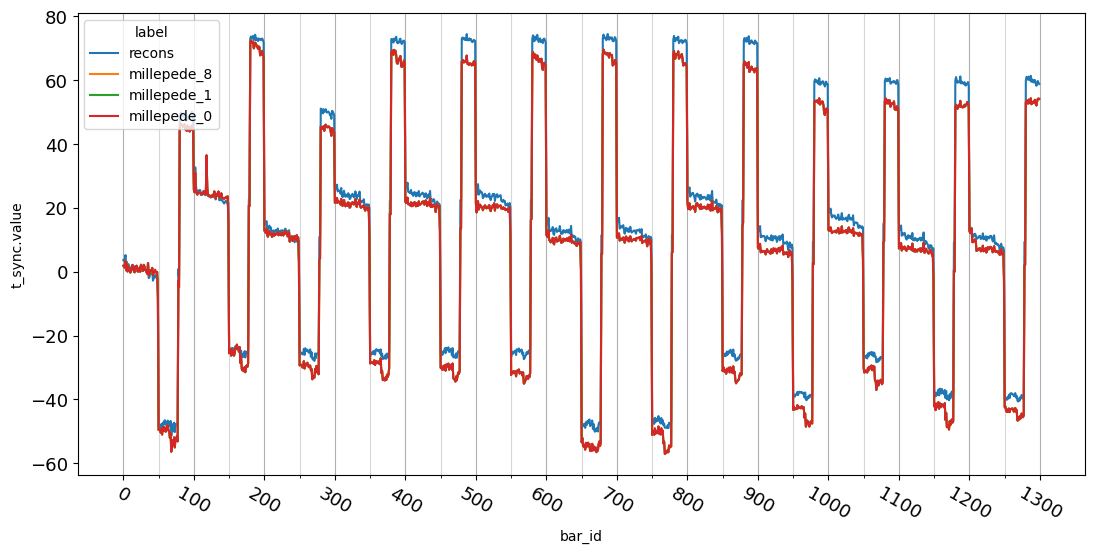

In [23]:
plot, axes = compare_par("t_sync.value", all_pars, plot_labels)
# axes.set(ylim=(-10, 20));
# axes.set(xlim=(1200, 1300))

### Comparison of t_diff parameter

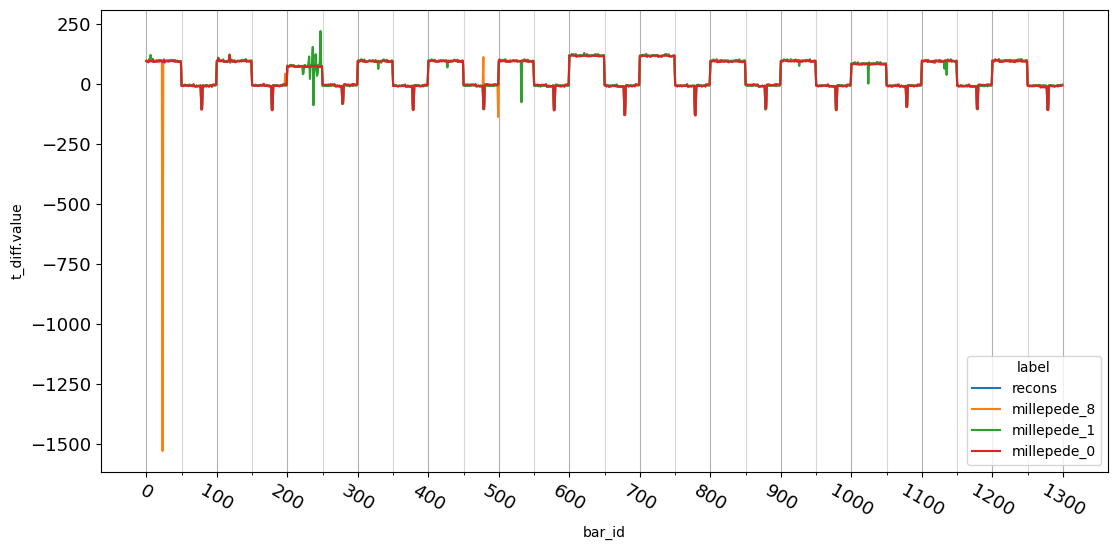

In [24]:
plot, axes = compare_par("t_diff.value", all_pars, plot_labels)
# axes.set(ylim=(-80, 80));
# axes.set(xlim=(0, 50));

### Comparison of effective speed of light parameter

(0.0, 5.0)

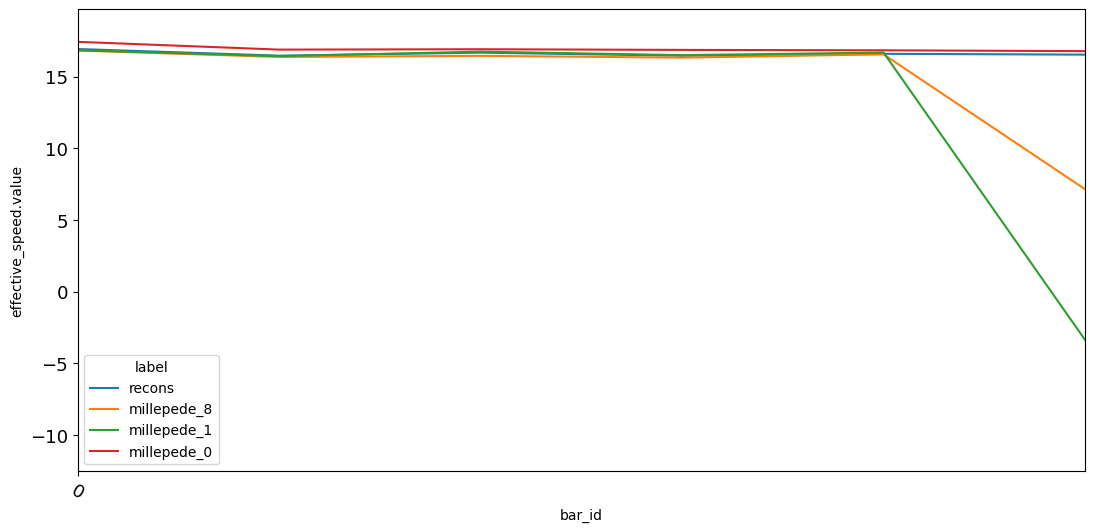

In [29]:
plot, axes = compare_par("effective_speed.value", all_pars, plot_labels)
# axes.set_ylim(10, 25)
axes.set_xlim(0, 5)

### Error checking

In [10]:
last_iter_par = all_pars[all_pars["iteration"] == iter_max_num]
last_iter_par

,bar_id,t_diff.error,t_diff.value,t_sync.error,t_sync.value,effective_speed.error,effective_speed.value,light_attenuation_length.error,light_attenuation_length.value,light_attenuation_factor.error,...,pmt_saturation.left.value,pmt_saturation.left.error,pmt_saturation.right.value,pmt_saturation.right.error,pmt_threshold.left.value,pmt_threshold.left.error,pmt_threshold.right.value,pmt_threshold.right.error,iteration,label
0,0.0,3.288851,98.056389,1.076055,6.617487,0.135928,14.526592,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,millepede_8
1,1.0,3.249406,94.986746,0.884466,5.786530,0.135080,14.040454,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,millepede_8
2,2.0,3.502107,96.742840,1.087550,5.123304,0.142630,14.050575,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,millepede_8
3,3.0,3.337366,93.613568,1.115777,6.818310,0.137800,13.716593,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,millepede_8
4,4.0,5.677704,103.030814,1.095337,3.051494,0.209395,14.007665,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,millepede_8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,1295.0,0.321422,-4.661748,9.937985,50.420322,0.230519,14.184026,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,millepede_8
1296,1296.0,0.361322,-5.484318,9.860738,51.130066,0.229820,14.253353,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,millepede_8
1297,1297.0,0.300514,-3.949259,9.892674,51.850344,0.236296,14.090841,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,millepede_8
1298,1298.0,0.436932,-4.682735,9.889558,51.161100,0.298257,14.143683,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,millepede_8


(0.0, 50.0)

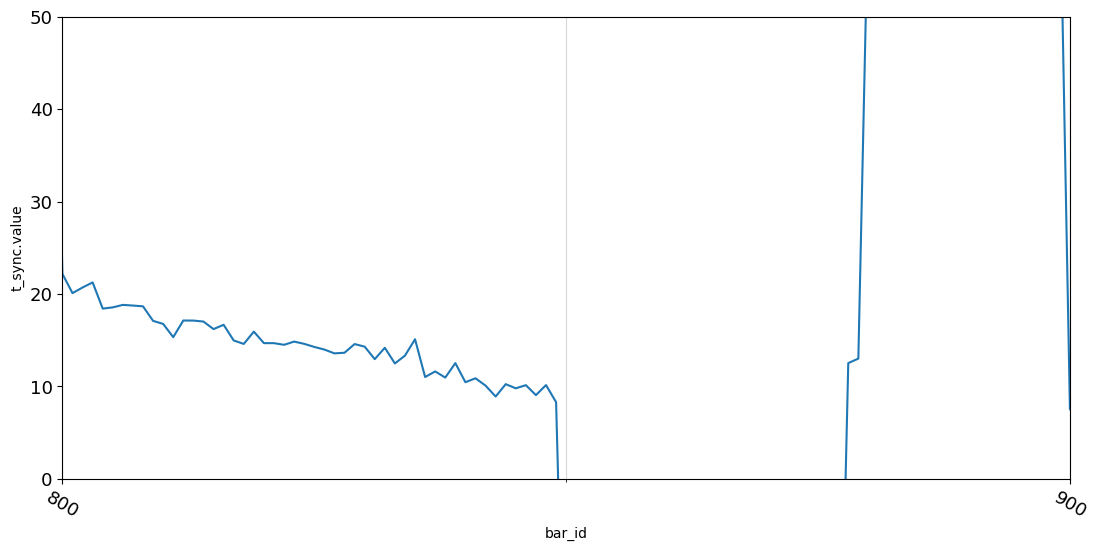

In [68]:
hit_par = r3b.neuland.HitParReader(
    f"{root_path}/{dir_path}/millepede.test1.par.root", is_verbose=False
)
df = hit_par.read(False)
plot, axis = show_par_with_errors("t_sync", df, alpha=0.5)
axis.set_xlim(800, 900)
axis.set_ylim(0, 50)